In [1]:
include("LST_BEK.jl")
using Plots
using LinearAlgebra

In [ ]:
function eigvector(eigval,values,vec)
    index = findall(x-> x== eigval,values)
    vector = vec[:,index] 
    return vector
end
function RQI(A, B, sigma; q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
end

In [131]:
baseflow = "Vonkarmen.txt"
N = 199
α = 0.4
β = 0.1
R = 400
Ro = -1 
Co = 2
A,B = KEB_TimeMode.KEB_LST_all(baseflow,N,α,β,R,Ro,Co)
C = eigen(A,B)
vals = C.values
vecs = C.vectors
val1 = filter(x->abs.(real(x))<0.01 && 0 < imag(x),vals)
vec = eigvector(val1[1],vals,vecs)
@show val1

val1 = ComplexF64[0.009740943018743457 + 0.003217934257735549im]


1-element Vector{ComplexF64}:
 0.009740943018743457 + 0.003217934257735549im

In [134]:
val_all = []
val0,vec0 = val1[1],vec
for β =0.1 : -0.001 : 0
    A,B = KEB_TimeMode.KEB_LST_all(baseflow,N,α,β,R,Ro,Co)
    val_temp,vec_temp = RQI(A,B,val0,q0=vec0)
    val0,vec0 = val_temp,vec_temp
    val_all = [val_all;val0]
end

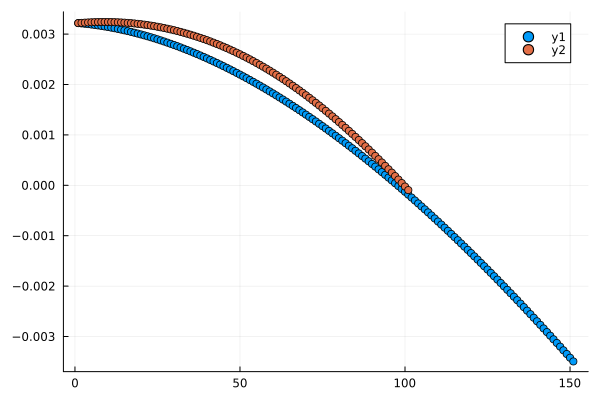

In [135]:
scatter!(imag(val_all))

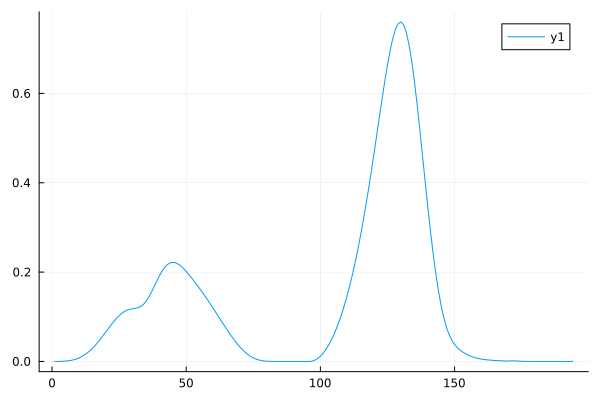

In [47]:
plot(abs.(vec))

In [ ]:
rayleigh_quotient_iteration(A, B, sigma; q0=rand(size(A, 1), 1))